In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
import time as _time
from tqdm import trange

FILE_PATH = os.getcwd()
sys.path.append(os.path.join(FILE_PATH, '..'))
import plot_settings
plot_settings.apply()

COLORS    = plot_settings.colors()
DATA_DIR  = os.path.join(FILE_PATH, 'Multi_data')
DATA_FILE = os.path.join(DATA_DIR, 'polished_DC/2_merged_data.txt')
DT        = 1.0

PULSE_FILE  = os.path.join(DATA_DIR, 'polished_pulses/data_pulse1.txt')
SAVE_FIGS   = False
SAVE_PULSE_FIGS = False

Q0          = 17921.57581



print("Loading data...")
data = pd.read_csv(DATA_FILE, sep=';', comment='%')
print(data.columns)
data['eta'] = -data['eta']
I_MAX = data['I'].max()

pulse_raw = pd.read_csv(PULSE_FILE, sep=',', comment='%')
print(pulse_raw.columns)
pulse_raw['eta'] = pulse_raw['eta']

def prepare_pulse_data(pulse_raw):
    pulse_trajs = []
    for _, grp in pulse_raw.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)
        pulse_trajs.append(dict(
            I     = grp['I'].values,
            u     = float(grp['u'].iloc[0]),
            soc0  = float(grp['soc'].iloc[0]),
            T     = len(grp),
            t     = grp['t'].values,
            V     = grp['V'].values,
            F     = grp['F'].values,
            soc   = grp['soc'].values,
            c     = grp['C'].values.astype(np.float32),
            eta   = grp['eta'].values.astype(np.float32),
            Ue   = grp['Ue'].values,
        ))
    return pulse_trajs

pulse_trajs = prepare_pulse_data(pulse_raw)

import GP
# GP_FIT = GP.GP_process()

Loading data...
Index(['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'eta', 'trajectory', 'dV',
       'dF', 'soc'],
      dtype='object')
Index(['u_par', 'C', 't', 'V', 'F', 'u', 'Ue', 'soc', 'I', 'trajectory',
       'eta'],
      dtype='object')


In [2]:
# ── Load data ──────────────────────────────────────────────
data = pd.read_csv(DATA_FILE, sep=';', comment='%')
data['eta'] = -data['eta']

# Build OCV interpolator from data (same as battery models)
_s, _u = data['soc'].values, data['Ue'].values
_i = np.argsort(_s)
Ue_interp = interp1d(_s[_i], _u[_i], kind='linear', fill_value='extrapolate')

print(f"  {len(data)} pts, {data['trajectory'].nunique()} trajectories")

# ── Build trajectories ─────────────────────────────────────
def prepare_data(data):
    trajs = []
    for _, grp in data.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)
        I_val, u_val = float(grp['I'].iloc[0]), float(grp['u'].iloc[0])
        soc_arr = grp['soc'].values.astype(np.float32)
        trajs.append(dict(
            I     = grp['I'].values,
            u     = float(grp['u'].iloc[0]),
            soc0  = float(grp['soc'].iloc[0]),
            T     = len(grp),
            t     = grp['t'].values,
            V     = grp['V'].values,
            F     = grp['F'].values,
            soc   = grp['soc'].values,
            c     = grp['C'].values.astype(np.float32),
            eta   = grp['eta'].values.astype(np.float32),
            Ue   = grp['Ue'].values,
            u_par = float(grp['u_par'].iloc[0]),
        ))
    return trajs

trajs = prepare_data(data)
print(f"  {len(trajs)} trajectories prepared")

  415557 pts, 248 trajectories
  248 trajectories prepared


In [3]:
# --- ODE solver---
def simulate_ode(t, i_profile, ocv, p):
    """
    t          : 1-D time array (s)
    i_profile  : 1-D current array, same length as t
    ocv        : 1-D open circuit voltage array, same length as t
    """
    def current(t_scalar):
        return np.interp(t_scalar, t, i_profile)

    def dU1(u, t_s):               # RC voltage ODE
        return -u / (p['R1'] * p['C1']) + current(t_s) / p['C1']

    def dSOC(z, t_s):              # SOC ODE
        return -current(t_s) / p['Q']

    U1  = scipy.integrate.odeint(dU1,  0.0, t, args=()).flatten()
    soc = scipy.integrate.odeint(dSOC, 1.0, t, args=()).flatten()

    V   = ocv - i_profile * p['R0'] - U1
    return V, soc, U1

In [4]:
LIMS = {
    'R0': (0.001, 0.1),   # Ohm
    'R1': (0.001, 0.5),   # Ohm
    'C1': (500, 2.5e4),   # F
    'R2': (0.001, 0.1),   # Ohm
    'C2': (100, 1e4),   # F
}

In [5]:
def ECM_solve_tau(theta, i, t):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,tau,gamma):
        I_t = I_interp(t)
        return -u / tau + I_t * gamma

    # Solve ODE
    R0, tau , gamma = theta
    U1 = scipy.integrate.odeint(dU, 0.0, t, args=(tau,gamma)).flatten()
    #U2 = 0

    U = U1 
    # Voltage model
    eta_model =  i*R0 + U

    return eta_model

def ECM_solve_du(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model


def ECM_solve(theta, i, t):
    R0, R1 , C1 = theta

    eta_model = i * (R0 + R1 * (1 - np.exp(-t/(R1*C1))))
    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du(theta=[R0, R1, C1], i=i, t=t)
    return eta_model

def dSOC_dt(z,t, i):              # SOC ODE
    return  -i / Q0


In [6]:
def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])

    xdata = [tr['t'], tr['I']]
    ydata = tr['eta']
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return R0, R1, C1,eta

R0 estimate: 0.0077 Ohm


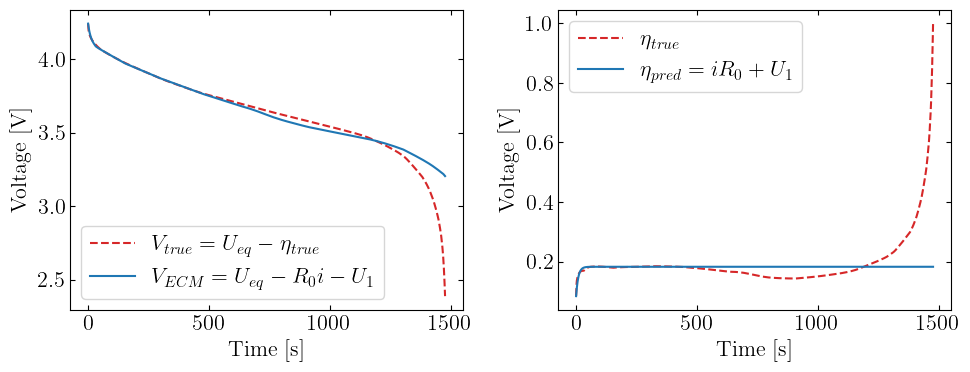

In [7]:
idx = 0
traj = trajs[idx]   # Just take the first trajectory for testing

tr = pd.DataFrame(traj)  # Convert to DataFrame for easier handling

#tr = tr[tr['t'] < 600]  # Limit to first 200 seconds for better visualization
#tr 

def R0_func(u, I):
    return u * (-0.0001887521) - 7.049519e-5 * I + 0.008446693

print(f"R0 estimate: {R0_func(tr['u'], tr['I'])[10]:.4f} Ohm")
params = dict(
    R0=R0_func(tr['u'], tr['I']),
    R1=0.009,
    C1=1000,
    Q=17921.57581,       # match Q0 from the battery models
)

eta = ECM_solve_du(theta=[params['R0'], params['R1'], params['C1']], i=tr['I'], t=tr['t'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
#axes[0].plot(tr['t'], GP.soc_to_Ue(tr['soc'], GP_FIT), color=COLORS[1], linestyle=':', label=r'$U_{eq}$')
axes[0].plot(tr['t'], tr['V'], color=COLORS[1], linestyle='--', label=r'$V_{true} = U_{eq} - \eta_{true}$')
axes[0].plot(tr['t'], -eta + tr['Ue'], color=COLORS[0], label=r'$V_{ECM} = U_{eq} - R_0 i - U_1$')
axes[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Voltage [V]'); axes[0].legend()

axes[1].plot(tr['t'], tr['eta'] , color=COLORS[1], linestyle='--', label=r'$\eta_{true}$')
axes[1].plot(tr['t'], eta, color=COLORS[0], label=r'$\eta_{pred} = iR_0 + U_1$')
axes[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Voltage [V]'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FILE_PATH, 'ecm_ode.pdf'), bbox_inches='tight')

In [8]:
start_time = _time.perf_counter()
R0, R1, C1, eta_1 = parameter_estimation_curvefit(tr)
end_time = _time.perf_counter()
print(f"Parameter estimation took {(end_time - start_time):.2f} seconds")
print(f"Estimated parameters for trajectory: R0={R0:.4f} Ohm, R1={R1:.4f} Ohm, C1={C1:.2f} F")

Parameter estimation took 0.15 seconds
Estimated parameters for trajectory: R0=0.0128 Ohm, R1=0.0055 Ohm, C1=25000.00 F


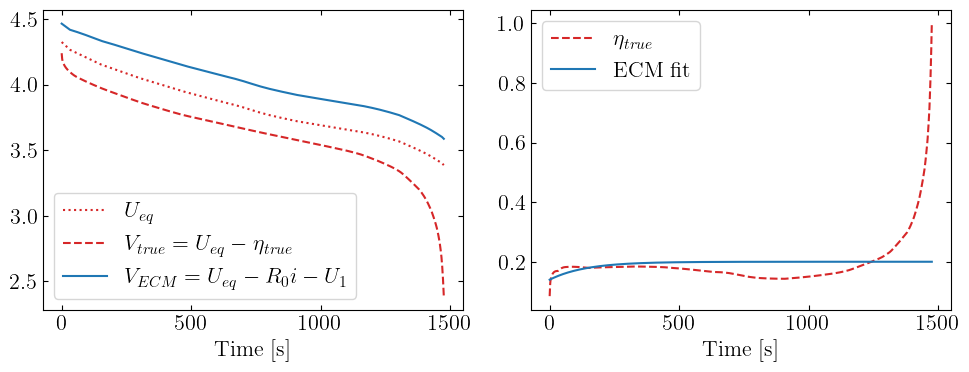

In [9]:
f, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(tr['t'], tr['Ue'], color=COLORS[1], linestyle=':', label=r'$U_{eq}$')
ax[0].plot(tr['t'], tr['V'], color=COLORS[1], linestyle='--', label=r'$V_{true} = U_{eq} - \eta_{true}$')
ax[0].plot(tr['t'], eta_1 + tr['Ue'], color=COLORS[0], label=r'$V_{ECM} = U_{eq} - R_0 i - U_1$')
ax[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Voltage [V]'); axes[0].legend() 

ax[1].plot(tr['t'], tr['eta'] , color=COLORS[1], linestyle='--', label=r'$\eta_{true}$')
ax[1].plot(tr['t'], eta_1, color=COLORS[0], label=r'ECM fit ')
ax[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Voltage [V]'); axes[1].legend()
for a in ax:
    a.legend()

plt.tight_layout()
#plt.plot(tr['t'], eta_1, label='ECM Fit 1RC', color=COLORS[0])
#plt.plot(tr['t'], -tr['eta'], label='Data', color=COLORS[1], ls = '--')

In [10]:
# def ECM_solve_curvefit_2RC(x, R0, R1, C1, R2, C2):
#     t, i = x
#     eta_model = ECM_solve_du(theta=[R0, R1, C1, R2,C2], i=i, t=t, RC2=True)
#     return eta_model


# def parameter_estimation_curvefit_2RC(tr, p0=[0.01, 0.01, 1500, 0.01, 1500], lims=LIMS):
#     bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0], lims['R2'][0], lims['C2'][0]], 
#               [lims['R0'][1], lims['R1'][1], lims['C1'][1], lims['R2'][1], lims['C2'][1]])

#     xdata = [tr['t'], tr['I']]
#     ydata = -tr['eta']
#     popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit_2RC, xdata, ydata, p0=p0, bounds=bounds)
#     R0, R1 , C1, R2, C2 = popt
#     eta = ECM_solve_curvefit_2RC(xdata, R0, R1, C1, R2, C2)
#     return R0, R1, C1, R2, C2, eta

In [11]:
#R0, R1, C1, R2, C2, eta_2 = parameter_estimation_curvefit_2RC(tr, p0=[0.01, 0.01, 1500, 0.01, 1500], lims=LIMS)
#print(f"Estimated parameters for trajectory\nR0={R0:.4f} Ohm,\nR1={R1:.4f} Ohm,\nC1={C1:.2f} F,\nR2={R2:.4f} Ohm,\nC2={C2:.2f} F")

In [12]:
# rmse = np.zeros(len(trajs))
# I = np.zeros(len(trajs)) 
# u = np.zeros(len(trajs))
# for i,tr in enumerate(trajs):
#     R0, R1, C1, eta_1 = parameter_estimation_curvefit(tr)
#     rmse[i] = np.sqrt(np.mean((eta_1 - (tr['eta']))**2))
#     I[i] = tr['c'].max()
#     u[i] = tr['u_par']
    
#     print(f"Estimated parameters for trajectory\nR0={R0:.4f} Ohm,\nR1={R1:.4f} Ohm,\nC1={C1:.2f} F")



In [13]:

results = []
for i, ptr in enumerate(pulse_trajs):
    ptr = pd.DataFrame(ptr)
    t_t_max = ptr['t'].max()
    C_max = ptr['c'].max()

    segment_length = 300
    n_segments = int(np.ceil(t_t_max / segment_length))

    for j in trange(n_segments):
        start = j * segment_length
        end = min((j + 1) * segment_length, t_t_max)

        t_t = ptr[(ptr['t'] > start ) & (ptr['t'] < end)].copy()

        if len(t_t) == 0:
            continue

        t_t['t'] = np.arange(len(t_t))

        R0, R1, C1, eta_1 = parameter_estimation_curvefit(
            t_t,
            U0=-t_t['eta'].values[0]
        )
        results.append({
            'trajectory': i,
            'segment': j,
            'C-max': C_max,
            'R0': R0,
            'R1': R1,
            'C1': C1,
            'soc': t_t['soc'].values.mean(),
            'eta_true':t_t['eta'].values,
            'eta_1' : ECM_solve_du(theta=[R0, R1, C1], i=t_t['I'], t=t_t['t'])
        })
        
results_df = pd.DataFrame(results)
print(results_df.head())
    

100%|██████████| 21/21 [00:00<00:00, 30.34it/s]

   trajectory  segment  C-max        R0        R1           C1       soc  \
0           0        0    1.9  0.012230  0.005584  2206.494360  0.920836   
1           0        1    1.9  0.010000  0.010000  1500.000000  0.841672   
2           0        2    1.9  0.008917  0.008065  5282.541457  0.762503   
3           0        3    1.9  0.010000  0.010000  1500.000000  0.683340   
4           0        4    1.9  0.007110  0.007708  2315.732467  0.604172   

                                            eta_true  \
0  [0.10070192, 0.113986574, 0.12409294, 0.131065...   
1  [0.10727213, 0.09985803, 0.093955584, 0.089067...   
2  [0.06477667, 0.072396934, 0.078466885, 0.08337...   
3  [0.10583547, 0.09970287, 0.09463775, 0.0903286...   
4  [0.06089831, 0.067915246, 0.07365398, 0.078495...   

                                               eta_1  
0  1      0.115677
2      0.119794
3      0.12359...  
1  301    0.0
302    0.0
303    0.0
304    0.0
30...  
2  601    0.084343
602    0.086113
603   

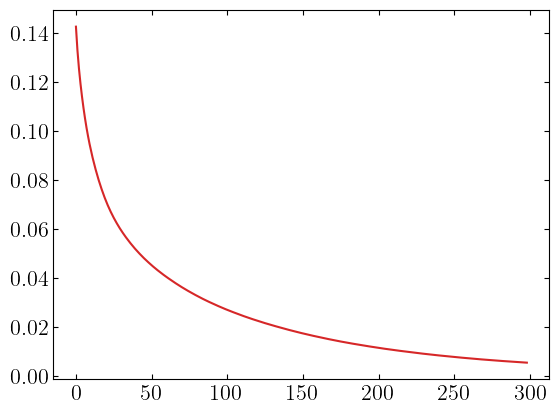

In [14]:
plt.plot(results_df['eta_true'][(results_df['trajectory'] == 10) & (results_df['segment'] % 2 ==1)].values[0], label='True', color=COLORS[1])

In [15]:

# results = []
# for i, ptr in enumerate(trajs):
#     ptr = pd.DataFrame(ptr)
#     SOC_min = ptr['soc'].min()
#     C_max = ptr['c'].max()
#     d_soc = ptr['soc'].max() - ptr['soc'].min()

#     segment_length = 0.05
#     n_segments = int(np.ceil(d_soc / segment_length))
#     print(f'Traj {i}, n_segments: {n_segments}')

#     for j in range(n_segments):
#         start = j * segment_length
#         end = min((j + 1) * segment_length, SOC_min + d_soc)

#         t_t = ptr[(ptr['soc'] > start) & (ptr['soc'] < end)].copy()

#         if len(t_t) == 0:
#             continue

#         t_t['t'] = np.arange(len(t_t))

#         R0, R1, C1, eta_1 = parameter_estimation_curvefit(
#             t_t,
#             U0=-t_t['eta'].values[0]
#         )
#         results.append({
#             'trajectory': i,
#             'segment': j,
#             'C-max': C_max,
#             'R0': R0,
#             'R1': R1,
#             'C1': C1,
#             'soc': t_t['soc'].values.mean()})
     

In [16]:
results_df = pd.DataFrame(results)
print(results_df.head())

   trajectory  segment  C-max        R0        R1           C1       soc  \
0           0        0    1.9  0.012230  0.005584  2206.494360  0.920836   
1           0        1    1.9  0.010000  0.010000  1500.000000  0.841672   
2           0        2    1.9  0.008917  0.008065  5282.541457  0.762503   
3           0        3    1.9  0.010000  0.010000  1500.000000  0.683340   
4           0        4    1.9  0.007110  0.007708  2315.732467  0.604172   

                                            eta_true  \
0  [0.10070192, 0.113986574, 0.12409294, 0.131065...   
1  [0.10727213, 0.09985803, 0.093955584, 0.089067...   
2  [0.06477667, 0.072396934, 0.078466885, 0.08337...   
3  [0.10583547, 0.09970287, 0.09463775, 0.0903286...   
4  [0.06089831, 0.067915246, 0.07365398, 0.078495...   

                                               eta_1  
0  1      0.115677
2      0.119794
3      0.12359...  
1  301    0.0
302    0.0
303    0.0
304    0.0
30...  
2  601    0.084343
602    0.086113
603   

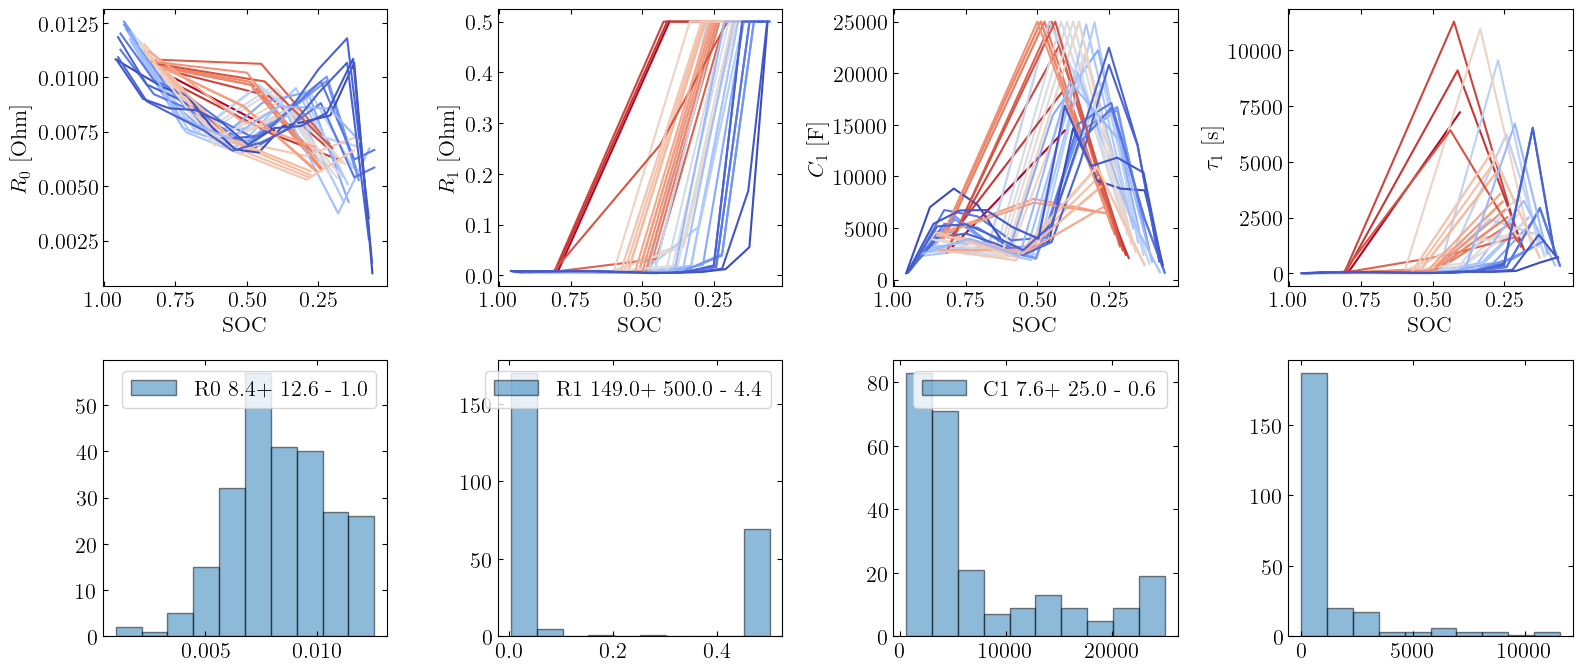

In [17]:
import matplotlib as mpl
df = results_df
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=df['C-max'].min(), vmax=df['C-max'].max())
f,axs = plt.subplots(2,4,figsize=(16,7))
for i in df['trajectory'].unique():
    mean_I = df.loc[df['trajectory'] == i, 'C-max'].mean()
    color = cmap(norm(mean_I))
    
    if i < 10:
        pass
    else:
        axs[0,0].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R0'],
            color=color
        )
        axs[0,1].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0),'R1'],
            color=color
        )
        axs[0,2].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0),'C1'],
            color=color
        )
        axs[0,3].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0),'C1'] * df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))&(df['segment'] % 2 == 0),'R1'],
            color=color
        )

for a in axs[0,:].flatten():
    a.set_xlabel('SOC')
    a.invert_xaxis()
    
axs[1,0].hist(df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R0'], color=COLORS[0], alpha=0.5, edgecolor='black', label=f'R0 {1000*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R0'].mean():.1f}+ {1000*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R0'].max():.1f} - {1000*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R0'].min():.1f}')
axs[1,0].legend()
axs[1,1].hist(df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R1'], color=COLORS[0], alpha=0.5, edgecolor='black', label=f'R1 {1000*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R1'].mean():.1f}+ {1000*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R1'].max():.1f} - {1000*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'R1'].min():.1f}')
axs[1,1].legend()
axs[1,2].hist(df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'C1'], color=COLORS[0], alpha=0.5,edgecolor='black', label =f'C1 {0.001*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'C1'].mean():.1f}+ {0.001*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'C1'].max():.1f} - {0.001*df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'C1'].min():.1f}')
axs[1,2].legend()
axs[1,3].hist(df.loc[((df['C-max'] < 4.95)) & (df['segment'] % 2 == 0),'C1'] * df.loc[((df['C-max'] < 4.95))&(df['segment'] % 2 == 0),'R1'], color=COLORS[0], alpha=0.5, edgecolor='black')




axs[0,0].set_ylabel('$R_0$ [Ohm]')
axs[0,1].set_ylabel('$R_1$ [Ohm]')
axs[0,2].set_ylabel('$C_1$ [F]')
axs[0,3].set_ylabel(r'$\tau_1$ [s]')
plt.tight_layout()

In [18]:
print(df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))& (df['segment'] % 2 == 0),'C1'] * df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95))&(df['segment'] % 2 == 0),'R1'],)

421       5.527955
423      41.643352
425      55.435330
427      55.016800
429      34.820135
431      21.574350
433      88.040259
435      75.362858
437     157.958445
439    1731.064179
441     661.675877
dtype: float64


[39.83875  38.03916  35.92435  32.28736  29.80123  30.51824  31.95452
 35.06925  36.39394  48.65906  43.27146  38.4674   33.98307  35.3138
 32.48708  41.27552  40.12411  35.76298  54.27536  45.10974  41.44448
 32.8536   34.13907  29.87088  40.48086  33.072    32.551    57.999249
 46.243456 44.124236 32.214766 32.943773 35.719382 41.977536 40.391963
 30.50803  59.53246  55.97004  35.99545  43.54472  31.4412   37.1434
 34.1968   37.72032  41.7563  ]


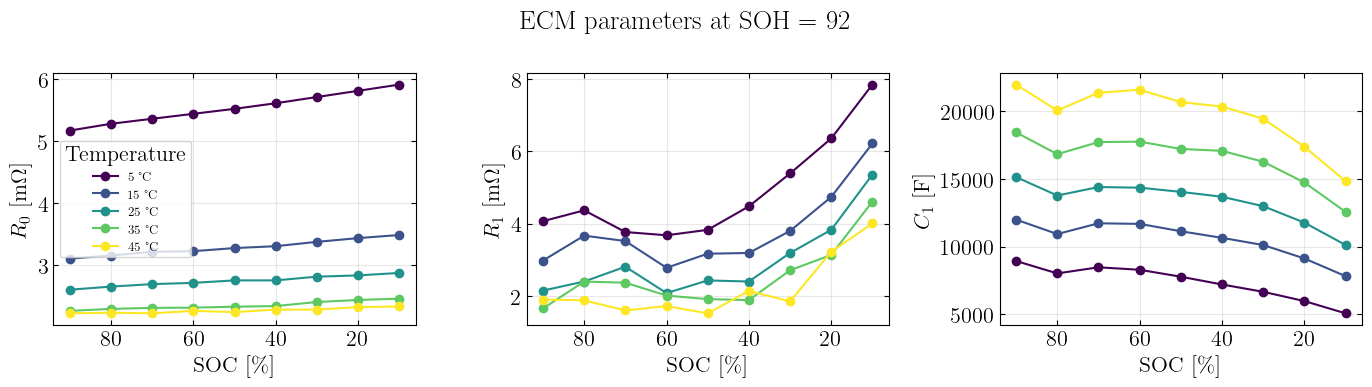

In [20]:
# Data: columns = Temp, SOC, R0, R1, C1
# Tran etal.
data = np.array([
    [ 5, 10, 5910, 7850,  5075],
    [ 5, 20, 5810, 6360,  5981],
    [ 5, 30, 5710, 5390,  6665],
    [ 5, 40, 5610, 4480,  7207],
    [ 5, 50, 5520, 3830,  7781],
    [ 5, 60, 5440, 3680,  8293],
    [ 5, 70, 5360, 3770,  8476],
    [ 5, 80, 5280, 4370,  8025],
    [ 5, 90, 5170, 4070,  8942],
    [15, 10, 3490, 6220,  7823],
    [15, 20, 3440, 4740,  9129],
    [15, 30, 3380, 3800, 10123],
    [15, 40, 3310, 3190, 10653],
    [15, 50, 3280, 3170, 11140],
    [15, 60, 3230, 2780, 11686],
    [15, 70, 3220, 3520, 11726],
    [15, 80, 3160, 3670, 10933],
    [15, 90, 3110, 2980, 12001],
    [25, 10, 2880, 5360, 10126],
    [25, 20, 2840, 3830, 11778],
    [25, 30, 2820, 3190, 12992],
    [25, 40, 2760, 2400, 13689],
    [25, 50, 2760, 2430, 14049],
    [25, 60, 2720, 2080, 14361],
    [25, 70, 2700, 2810, 14406],
    [25, 80, 2660, 2400, 13780],
    [25, 90, 2610, 2150, 15140],
    [35, 10, 2466, 4613, 12573],
    [35, 20, 2445, 3136, 14746],
    [35, 30, 2412, 2711, 16276],
    [35, 40, 2347, 1886, 17081],
    [35, 50, 2337, 1913, 17221],
    [35, 60, 2321, 2011, 17762],
    [35, 70, 2318, 2368, 17727],
    [35, 80, 2301, 2399, 16837],
    [35, 90, 2270, 1654, 18445],
    [45, 10, 2340, 4010, 14846],
    [45, 20, 2330, 3220, 17382],
    [45, 30, 2290, 1850, 19457],
    [45, 40, 2290, 2140, 20348],
    [45, 50, 2250, 1520, 20685],
    [45, 60, 2270, 1720, 21595],
    [45, 70, 2230, 1600, 21373],
    [45, 80, 2240, 1880, 20064],
    [45, 90, 2230, 1900, 21977],
])


print(data[:,3] * 1e-6 * data[:,4])

temps = np.unique(data[:, 0])
cmap  = plt.cm.viridis
norm  = plt.Normalize(temps.min(), temps.max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for T in temps:
    sub = data[data[:, 0] == T]
    soc = sub[:, 1]
    color = cmap(norm(T))
    axes[0].plot(soc, sub[:, 2] / 1000, '-o', color=color, label=f'{T:.0f} °C')  # R0 mΩ
    axes[1].plot(soc, sub[:, 3] / 1000, '-o', color=color)                       # R1 mΩ
    axes[2].plot(soc, sub[:, 4],        '-o', color=color)                       # C1 F

axes[0].set_ylabel(r'$R_0$ [m$\Omega$]')
axes[1].set_ylabel(r'$R_1$ [m$\Omega$]')
axes[2].set_ylabel(r'$C_1$ [F]')
for ax in axes:
    ax.set_xlabel(r'SOC [$\%$]')
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
axes[0].legend(title='Temperature', fontsize=9)

fig.suptitle('ECM parameters at SOH = 92%')
fig.tight_layout()
plt.show()

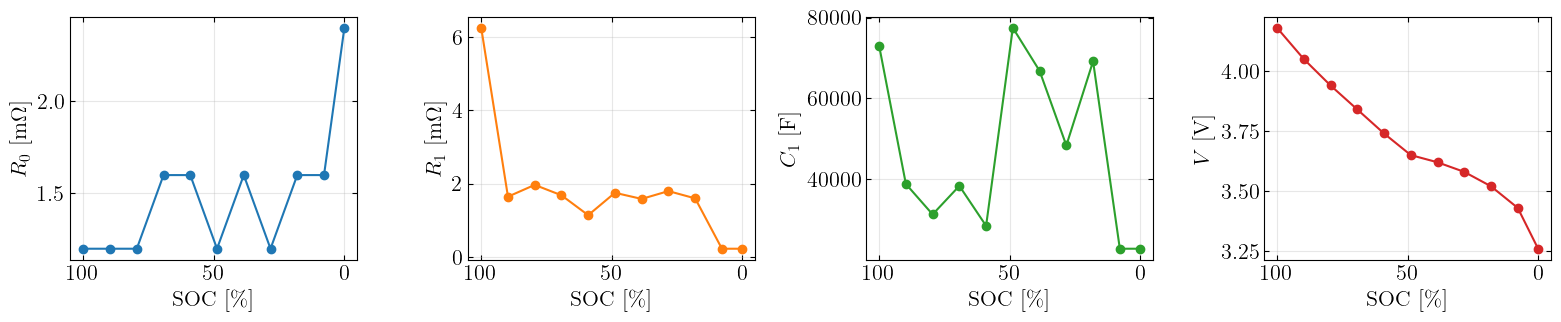

In [144]:
# Second dataset: columns = SOC, R0, C1, R1, V
# (temperature not specified)
# Wang etal.

data2 = np.array([
    [1.000000, 0.0012, 73021.9735, 0.0062532, 4.18],
    [0.897584, 0.0012, 38779.0975, 0.0016404, 4.05],
    [0.795148, 0.0012, 31237.4083, 0.0019628, 3.94],
    [0.692691, 0.0016, 38306.3389, 0.0016788, 3.84],
    [0.590254, 0.0016, 28407.8836, 0.0011348, 3.74],
    [0.487797, 0.0012, 77466.2222, 0.0017468, 3.65],
    [0.385340, 0.0016, 66796.6261, 0.0015792, 3.62],
    [0.282884, 0.0012, 48324.2877, 0.0017932, 3.58],
    [0.180447, 0.0016, 69167.8689, 0.0015940, 3.52],
    [0.077990, 0.0016, 22738.2283, 0.0002188, 3.43],
    [0.000000, 0.0024, 22738.2283, 0.0002188, 3.26],
])

soc2 = data2[:, 0] * 100   # fraction → %
R0_2 = data2[:, 1] * 1000  # Ω → mΩ
C1_2 = data2[:, 2]         # F
R1_2 = data2[:, 3] * 1000  # Ω → mΩ
V_2  = data2[:, 4]         # V

fig2, axes2 = plt.subplots(1, 4, figsize=(16, 3.5))
axes2[0].plot(soc2, R0_2, '-o', color='C0')
axes2[0].set_ylabel(r'$R_0$ [m$\Omega$]')
axes2[1].plot(soc2, R1_2, '-o', color='C1')
axes2[1].set_ylabel(r'$R_1$ [m$\Omega$]')
axes2[2].plot(soc2, C1_2, '-o', color='C2')
axes2[2].set_ylabel(r'$C_1$ [F]')
axes2[3].plot(soc2, V_2,  '-o', color='C3')
axes2[3].set_ylabel(r'$V$ [V]')
for ax in axes2:
    ax.set_xlabel(r'SOC [\%]')
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
fig2.tight_layout()

plt.show()